In [1]:
import spacy
from Bio import Entrez
import pandas as pd
import re
import ssl
import os
import ollama
import json
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
# 1. Ask user to input the variant they want to check
# Variant = input("Enter variant (e.g., BRCA1, V600E): ")
variant = "BRCA1 c.5266dupC"

# Option to filter by date
#use_date= input("Filter by year? ")
date_filter = "2024"

# Build search query with date filter
query = f"{variant} AND {date_filter}[PDAT]"

print(f"Gene: {variant}")
print(f"Date filter: {date_filter}")

Gene: BRCA1 c.5266dupC
Date filter: 2024


In [4]:
#2. Download papers from PubMed 
from Bio import Entrez
from Bio import Medline

Entrez.email = "jawahir_noor@hotmail.com"


# Search
handle = Entrez.esearch(db="pubmed", term=query, retmax=10)
record = Entrez.read(handle)
ids = record["IdList"]
handle.close()

# Simpler approach using BioPython's built-in parser
# Fetch in Medline format
handle = Entrez.efetch(db="pubmed", id=ids, rettype="medline", retmode="text")
records = Medline.parse(handle)

papers_list = []
for record in records:
    papers_list.append({
        "title": record.get("TI", ""),
        "abstract": record.get("AB", ""),
        "pmid": record.get("PMID", "")
    })
handle.close()

print(papers_list)



[{'title': 'Molecular analysis of BRCA1 and BRCA2 genes in La Rioja (Spain): five new variants.', 'abstract': 'BACKGROUND: To study BRCA1/2 gene variants in La Rioja in the northcentral area of Spain. METHODS: We performed a molecular analysis of BRCA1 and BRCA2 in 642 individuals from 427 different families from June 2008 to December 2019. RESULTS: We identified 71 families with pathogenic variants in these genes, 32 families with BRCA1 variants and 39 families with BRCA2 variants. The pathogenic variants c.959delG in BRCA1 and c.1363_1369delTCAGAGA, c.1397dupA, c.4234_4236delACTinsC and c.8387delC in BRCA2 have not been previously described. The c.81-2 A > T variant in BRCA1, detected in two unrelated families, has not been reported previously in the Spanish population. Two large genomic deletions were found in the BRCA1 gene in exons (Ex) 23-24 and Ex1A-1B-2, and one deletion was found in the BRCA2 gene in Ex2. The pathogenic variant c.5123 C > A in BRCA1 was detected in 8 unrelated

In [5]:
#3. Load model (BioNLP13CG)

# BioNLP model (biomedical entities)
nlp_bionlp = spacy.load("en_ner_bionlp13cg_md")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [6]:
#4. Extract biomedical entities (BioNLP13CG ) paper by paper
import pandas as pd
import re

results = []


for i, paper in enumerate(papers_list):

    text = paper["abstract"]

    if not text:
        continue

    # safe limit
    text = text[:5000]

    
    doc_bio = nlp_bionlp(text)

    # BioNLP entities
    for ent in doc_bio.ents:
        results.append({
            "paper_id": i,
            "title": paper["title"],
            "text": ent.text,
            "label": ent.label_,
            "model": "BioNLP13CG"
        })

The BioNLP13CG model was used to extract biomedical entities such as genes, diseases, and organisms from the collected abstracts. However, this model does not capture structured genomic variant formats (e.g., c.6313delA or p.Arg175His), as it is not specifically trained for mutation recognition. 

To address this limitation, a rule-based approach using regular expressions is implemented to identify variant mentions based on common HGVS-like patterns. The extracted variants are then added to the results as a separate category, allowing the pipeline to combine machine learning-based entity recognition with rule-based mutation extraction for more complete genomic information retrieval.

In [7]:
 # 5. Extract mutation variants (Rule-based + regex) 
mutation_patterns = [
    r"c\.\d+(?:_\d+)?[A-Z]>[A-Z]",        # c.5266C>T  (strict: single base change)
    r"c\.\d+(?:_\d+)?dup[A-Z]?",           # c.5266dupC or c.5266dup
    r"c\.\d+(?:_\d+)?del[A-Z]*",           # c.5266del
    r"c\.\d+(?:_\d+)?ins[A-Z]+",           # c.5266insA
    r"p\.[A-Z][a-z]{2}\d+[A-Z][a-z]{2}",  # p.Gln1756Ter  (strict 3-letter AA)
    r"rs\d{4,}",                            # rs ID (min 4 digits to avoid false hits)
]

def is_valid_variant(v):
    """Reject malformed extractions like 'c1016d', single-letter hits, etc."""
    # Must start with c., p., or rs
    if not re.match(r"^(c\.|p\.|rs)", v, re.IGNORECASE):
        return False
    # c. variants must have a numeric position
    if v.startswith("c.") and not re.search(r"c\.\d+", v):
        return False
    return True
 
def extract_variants(text):
    variants = []
    for pattern in mutation_patterns:
        matches = re.findall(pattern, text)
        variants.extend(matches)
    return [v for v in set(variants) if is_valid_variant(v)]
 
variant_results = []
for i, paper in enumerate(papers_list):
    text = paper["abstract"]
    if not text:
        continue
    for variant_match in extract_variants(text[:5000]):
        variant_results.append({
            "paper_id": i,
            "title": paper["title"],
            "pmid": paper.get("pmid", ""),
            "variant": variant_match
        })

In [8]:
import ssl
import certifi
import requests
from urllib.parse import quote
import time

# Fix SSL on Mac
ssl_context = ssl.create_default_context(cafile=certifi.where())

LITVAR2_BASE = "https://www.ncbi.nlm.nih.gov/research/litvar2-api"

def litvar2_normalize(variant_name, gene_name):
    try:
        url = f"{LITVAR2_BASE}/variant/autocomplete/?query={quote(variant_name)}"
        r = requests.get(url, timeout=15, verify=certifi.where())
        time.sleep(0.34)

        if r.status_code != 200:
            print(f"    [debug] HTTP {r.status_code} for {variant_name}")
            return None

        candidates = r.json()
        if not candidates:
            return None

        best = None
        for candidate in candidates:
            if any(gene_name.upper() == g.upper() for g in candidate.get("gene", [])):
                best = candidate
                break
        if best is None and candidates:
            best = candidates[0]
        if best is None:
            return None

        rsid        = best.get("rsid", "N/A")
        litvar_name = best.get("name", variant_name)
        genes       = best.get("gene", [])
        pmids_count = best.get("pmids_count", 0)

        pmids = []
        if rsid != "N/A" and int(pmids_count) > 0:
            encoded_id = f"litvar%40{rsid}%23%23"
            pub_url = f"{LITVAR2_BASE}/variant/get/{encoded_id}/publications"
            r2 = requests.get(pub_url, timeout=15, verify=certifi.where())
            time.sleep(0.34)
            if r2.status_code == 200:
                pmids = r2.json().get("pmids", [])

        return {
            "rsid":        rsid,
            "litvar_name": litvar_name,
            "gene":        ", ".join(genes) if genes else gene_name,
            "pmids_count": pmids_count,
            "pmids":       pmids,
        }

    except Exception as e:
        print(f"    [debug] Exception for {variant_name}: {e}")
        return None

In [9]:
# 6.b. Build tables, normalize, print and save
os.makedirs("results", exist_ok=True)
 
df_entities = pd.DataFrame(results)
# Define gene from your variant
gene = variant.split()[0]
 
# Normalize via LitVar2 and add columns directly into variant_results rows
print("\nNormalizing variants via LitVar2...")
for row in variant_results:
    result = litvar2_normalize(row["variant"], gene)
 
    if result:
        row["rsid"]        = result["rsid"]
        row["litvar_name"] = result["litvar_name"]
        row["pmids_count"] = result["pmids_count"]
        row["litvar_pmids"] = "|".join(str(p) for p in result["pmids"][:5])  # first 5 PMIDs
        print(f"  {row['variant']} → {result['rsid']} | {result['litvar_name']} | {result['pmids_count']} papers")
    else:
        row["rsid"]        = "N/A"
        row["litvar_name"] = "N/A"
        row["pmids_count"] = 0
        row["litvar_pmids"] = "N/A"
        print(f"  {row['variant']} → Not found in LitVar2")
 
df_variants = pd.DataFrame(variant_results)
 
# Print 
print("\n=== Entities Found ===")
print(df_entities.head())
print(f"\nTotal entities: {len(df_entities)}")
 
print("\n=== Variants Found ===")
print(df_variants[["pmid", "variant", "rsid", "litvar_name", "pmids_count", "litvar_pmids"]].head(20))
print(f"\nTotal variants: {len(df_variants)}")
 
# Save 
df_entities.to_csv("results/paper_by_paper_entities.csv", index=False)
df_variants.to_csv("results/extracted_variants.csv", index=False)
 
print("\nResults saved to 'results/' directory")



Normalizing variants via LitVar2...
  c.1397dupA → rs864622132 | c.4709dupT | 4 papers
  c.6024dupG → rs80359554 | c.6024dupG | 31 papers
  c.2457delA → N/A | c.2457delA | 1 papers
  c.4038_4039delAA → rs273900721 | c.4038_4039delAA | 5 papers
  c.4234_4236delACT → Not found in LitVar2
  c.1363_1369delTCAGAGA → N/A | c.1363_1369delTCAGAGA | 1 papers
  c.8387delC → N/A | c.8387delC | 1 papers
  c.68_69delAG → rs80357914 | p.E23fsX | 140 papers
  c.2701delC → rs397507637 | c.2701delC | 11 papers
  c.5266dupC → rs80357906 | c.5266dupC | 476 papers
  c.2808_2011delACAA → N/A | c.2808_2011delACAA | 2 papers
  c.959delG → N/A | c.959delG | 1 papers
  c.6275delTT → N/A | c.6275delTT | 1 papers
  c.5116_5119delAATA → rs276174853 | c.5116_5119delAATA | 19 papers
  c.3207C>A → rs76151636 | p.H1069Q | 333 papers
  c.657_661del → rs587776650 | c.657_661delACAAA | 90 papers
  c.1222C>T → rs5030858 | p.R408W | 283 papers
  c.33C>A → rs35799536 | c.33C>A | 9 papers
  c.5266dupC → rs80357906 | c.5266

This code is a mini NLP pipeline using a local LLM (Large Language Model) (via Ollama) to extract structured genetic information from biomedical abstracts and save it to a CSV.

In [10]:
import ollama
import pandas as pd

# ── LLM extraction function ──
def biomistral_extract(text):
    prompt = f"""Extract the following from the abstract below.
Reply in exactly this format, nothing else:
Extract ONLY BRCA1-related information
Gene: <gene symbol>
Zygosity: <heterozygous/homozygous/compound heterozygous/not reported>
Clinical significance: <Pathogenic/Likely pathogenic/Uncertain significance/Benign/not reported>
Study type: <case report/cohort/functional/other/not reported>
Patient count: <number or not reported>
Functional evidence: <in vitro/splicing/animal model/biochemical/none/not reported>

Abstract:
{text[:1000]}"""

    try:
        response = ollama.chat(
            model='llama3.2',
            messages=[{'role': 'user', 'content': prompt}]
        )

        generated_text = response['message']['content']

        # ── default output ──
        result = {
            "gene_symbol_llm": "not reported",
            "zygosity_llm": "not reported",
            "clinical_sig_llm": "not reported",
            "study_type_llm": "not reported",
            "patient_count_llm": "not reported",
            "functional_evidence_llm": "not reported"
        }

        # ── parse LLM output ──
        for line in generated_text.splitlines():
            line = line.strip()

            if line.startswith("Gene:"):
                result["gene_symbol_llm"] = line.split(":", 1)[1].strip()

            elif line.startswith("Zygosity:"):
                result["zygosity_llm"] = line.split(":", 1)[1].strip()

            elif line.startswith("Clinical significance:"):
                result["clinical_sig_llm"] = line.split(":", 1)[1].strip()

            elif line.startswith("Study type:"):
                result["study_type_llm"] = line.split(":", 1)[1].strip()

            elif line.startswith("Patient count:"):
                result["patient_count_llm"] = line.split(":", 1)[1].strip()

            elif line.startswith("Functional evidence:"):
                result["functional_evidence_llm"] = line.split(":", 1)[1].strip()

        return result

    except Exception as e:
        print(f"Error processing abstract: {e}")

        return {
            "gene_symbol_llm": "not reported",
            "zygosity_llm": "not reported",
            "clinical_sig_llm": "not reported",
            "study_type_llm": "not reported",
            "patient_count_llm": "not reported",
            "functional_evidence_llm": "not reported"
        }

for i, paper in enumerate(papers_list[:6]):
    abstract = paper.get("abstract", "")

    if not abstract:
        continue

    r = biomistral_extract(abstract)

    print(
        f"Paper {i+1}: "
        f"Gene={r['gene_symbol_llm']} | "
        f"Zyg={r['zygosity_llm']} | "
        f"Clin={r['clinical_sig_llm']} | "
        f"Study={r['study_type_llm']} | "
        f"Patients={r['patient_count_llm']}"
    )

# Test on first 6 papers
results_llm = []

for p in papers_list:
    abstract = p.get("abstract", "")

    if not abstract:
        continue

    try:
        results_llm.append({
            "pmid": p.get("pmid", "unknown"),
            **biomistral_extract(abstract)
        })

    except Exception as e:
        print(f"Skipping PMID {p.get('pmid')} due to error: {e}")

df = pd.DataFrame(results_llm)
df.to_csv("llama_results.csv", index=False)

print("\nSaved to llama_results.csv")

Paper 1: Gene=BRCA1 | Zyg=not reported | Clin=Pathogenic | Study=Cohort | Patients=642 individuals from 427 families
Paper 2: Gene=BRCA1 | Zyg=not reported | Clin=Uncertain significance | Study=not reported | Patients=not reported
Paper 3: Gene=BRCA1 | Zyg=Compound heterozygous | Clin=Likely pathogenic | Study=Systematic review | Patients=55
Paper 4: Gene=BRCA1 | Zyg=Compound heterozygous | Clin=Pathogenic | Study=Cross-sectional study | Patients=45
Paper 5: Gene=BRCA1 | Zyg=Compound heterozygous | Clin=Pathogenic | Study=Systematic review | Patients=137 distinct mutations
Paper 6: Gene=BRCA1 | Zyg=<not reported> | Clin=Pathogenic | Study=Case report | Patients=Not reported

Saved to llama_results.csv


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import pandas as pd

# ── Gold standard — (mannually curated)
gold = [
    {
        "pmid": "39438962",
        "gene": "BRCA1",                  # 1.Molecular analysis of BRCA1 and BRCA2
        "zygosity": "heterozygous",
        "clinical_sig": "pathogenic"
    },
    {
        "pmid": "39273284",
        "gene": "BRCA1",                  # 2.The Spectrum of Disease-Associated...
        "zygosity": "not reported",
        "clinical_sig": "pathogenic"
    },
    {
        "pmid": "38918649",
        "gene": "BRCA1",                  # 3.A Systematic Review of the Prevalence
        "zygosity": "not reported",
        "clinical_sig": "pathogenic"
    },
    {
        "pmid": "38641594",
        "gene": "BRCA1",                  # 4.Germline mutations in BRCA1 and BRCA2
        "zygosity": "heterozygous",
        "clinical_sig": "pathogenic"
    },
    {
        "pmid": "38504328",
        "gene": "BRCA1",                  # 5.Systematic review of the molecular
        "zygosity": "not reported",
        "clinical_sig": "pathogenic"
    },
    {
        "pmid": "38386807",
        "gene": "BRCA1",                  # 6.Prevalence and spectrum of germline
        "zygosity": "heterozygous",
        "clinical_sig": "pathogenic"
    },
            ]

# ── Load LLM predictions ──
df_pred = pd.read_csv("llama_results.csv", dtype=str).fillna("not reported")
df_pred["pmid"] = df_pred["pmid"].astype(str).str.strip()


# ── Load data ──
df_pred = pd.read_csv("llama_results.csv", dtype=str).fillna("not reported")
df_pred["pmid"] = df_pred["pmid"].astype(str).str.strip()

gold_df = pd.DataFrame(gold)
gold_df["pmid"] = gold_df["pmid"].astype(str).str.strip()

# text cleaner ──
def clean_text(x):
    return str(x).lower().strip()

# ── Generic normalizer
def normalize_value(val, field):
    v = clean_text(val)


    if field == "zygosity":
        if "heterozygous" in v:
            return "heterozygous"
        if "homozygous" in v:
            return "homozygous"
        if "compound" in v:
            return "compound heterozygous"
        return "not reported"

    elif field == "clinical_sig":
        if "likely pathogenic" in v:
            return "likely pathogenic"
        if "pathogenic" in v:
            return "pathogenic"
        if "benign" in v:
            return "benign"
        if "uncertain" in v:
            return "uncertain significance"
        return "not reported"

    else:
        # fallback for new fields (study type, etc.)
        return v if v else "not reported"


# ── Define fields once (easy to extend) ──
fields = [
    ("Gene", "gene", "gene_symbol_llm"),
    ("Zygosity", "zygosity", "zygosity_llm"),
    ("Clinical significance", "clinical_sig", "clinical_sig_llm"),
]

# ── Apply normalization ──
for _, gold_col, pred_col in fields:
    gold_df[gold_col] = gold_df[gold_col].apply(lambda x: normalize_value(x, gold_col))
    df_pred[pred_col] = df_pred[pred_col].apply(lambda x: normalize_value(x, gold_col))

# ── Merge ──
merged = gold_df.merge(df_pred, on="pmid", how="inner")
print(f"Matched {len(merged)} of {len(gold_df)} papers\n")

# ── Evaluate ──
print(f"{'Field':<25} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 55)

for label, gold_col, pred_col in fields:
    y_true = merged[gold_col].tolist()
    y_pred = merged[pred_col].tolist()

    labels = sorted(set(y_true))

    p = precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    r = recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

    print(f"{label:<25} {p:>10.1%} {r:>8.1%} {f1:>8.1%}")

Matched 6 of 6 papers

Field                      Precision   Recall       F1
-------------------------------------------------------
Gene                          100.0%   100.0%   100.0%
Zygosity                       66.7%    66.7%    66.7%
Clinical significance         100.0%    50.0%    66.7%


This code evaluates how well the LLM extraction (from your CSV file) matches a manually curated gold standard dataset.
 First, it defines the gold data, where each paper (by PMID) has the correct gene, zygosity, and clinical significance labels. 
 Then it loads the LLM predictions from llama_results.csv, cleans the text by converting everything to lowercase and stripping spaces, 
 and merges the gold and predicted data using PMID so both datasets align. 
 After that, it compares the true vs predicted values for each field (gene, zygosity, and clinical significance) and 
 computes evaluation metrics—precision, recall, and F1-score using sklearn. 
 Finally, it prints a table showing how accurately the LLM performed for each category, using macro-averaging to treat all classes equally.

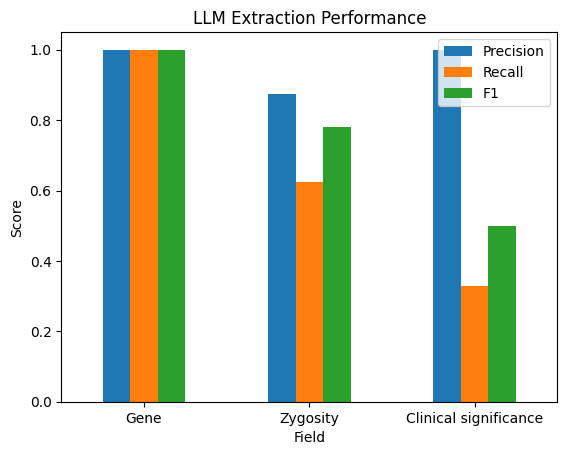

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Field": ["Gene", "Zygosity", "Clinical significance"],
    "Precision": [1.0, 0.875, 1.0],
    "Recall": [1.0, 0.625, 0.33],
    "F1": [1.0, 0.78, 0.50]
}
df = pd.DataFrame(data)
df.set_index("Field").plot(kind="bar")

plt.ylabel("Score")
plt.title("LLM Extraction Performance")
plt.xticks(rotation=0)
plt.show()

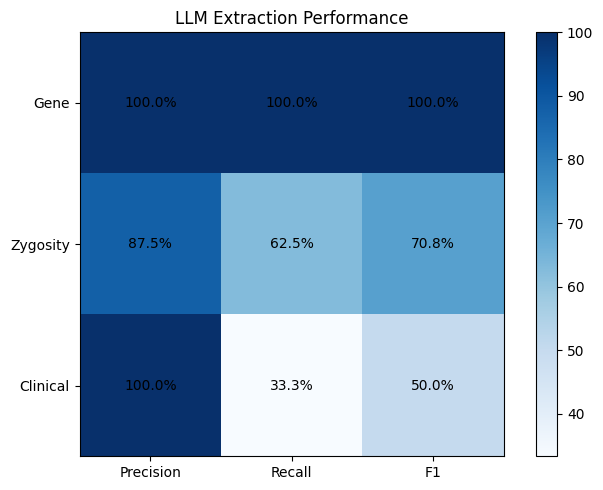

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──
fields = ["Gene", "Zygosity", "Clinical"]

scores = np.array([
    [100.0, 100.0, 100.0],  # Gene
    [ 87.5, 62.5,  70.8],   # Zygosity
    [100.0, 33.3,  50.0]    # Clinical
    ])

metrics = ["Precision", "Recall", "F1"]

# ── Plot ──
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(scores, cmap="Blues")

# ── Axis labels ──
ax.set_xticks(np.arange(len(metrics)))
ax.set_yticks(np.arange(len(fields)))
ax.set_xticklabels(metrics)
ax.set_yticklabels(fields)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# ── Add values inside cells ──
for i in range(len(fields)):
    for j in range(len(metrics)):
        ax.text(j, i, f"{scores[i, j]:.1f}%",
                ha="center", va="center", color="black")

# ── Title ──
ax.set_title("LLM Extraction Performance")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("llm_performance.png", dpi=300, bbox_inches='tight')

plt.show()